# 02 · Multi-touch attribution

**Question:** which marketing channels actually drive Google Merchandise Store purchases, and how much does the answer depend on the attribution model?

The heavy lifting runs in the dbt pipeline (`dbt build`), so this notebook only reads the finished tables from `warehouse.duckdb`:

| Table | What it holds |
|---|---|
| `intermediate.int_attribution__touchpoints` | each order's journey (sessions within a 30-day lookback) |
| `marts.mart_attribution_touch_credits` | per-touch credit under 6 rule-based models (SQL) |
| `marts.attribution_markov` | data-driven Markov chain removal effects + bootstrap CIs (Python) |
| `marts.mart_attribution_comparison` | all 7 models side by side |

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np

from marketing_analytics.style import PAL, apply, finish

apply()
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
IMG_DIR = PROJECT_ROOT / "figures"
con = duckdb.connect(str(PROJECT_ROOT / "warehouse.duckdb"), read_only=True)

BLUE, GREY, INK, INK_2, SURFACE = PAL["primary"], PAL["context"], PAL["ink"], PAL["ink_2"], PAL["surface"]
CHANNEL_ORDER = ["Organic Search", "Referral", "Direct", "Unknown", "Obfuscated", "Paid Search", "Email", "Affiliates"]

## 1 · Journeys: how many touches before a purchase?

In [2]:
con.sql("""
    WITH o AS (
        SELECT order_id, any_value(touches_in_path) AS touches, max(days_before_conversion) AS journey_days
        FROM intermediate.int_attribution__touchpoints GROUP BY order_id
    )
    SELECT count(*)                                             AS orders,
           round(100.0 * count_if(touches = 1) / count(*), 1)   AS pct_single_touch,
           round(avg(touches), 2)                               AS avg_touches,
           round(median(journey_days), 1)                       AS median_journey_days,
           round(quantile_cont(journey_days, 0.9), 1)           AS p90_journey_days
    FROM o
""").df()

,orders,pct_single_touch,avg_touches,median_journey_days,p90_journey_days
0,5288,64.5,1.65,0.0,12.9


In [3]:
# Most common converting paths
con.sql("""
    SELECT path_label, journeys AS orders, round(revenue_usd) AS revenue_usd
    FROM intermediate.int_attribution__paths
    WHERE converted ORDER BY journeys DESC LIMIT 15
""").df()

,path_label,orders,revenue_usd
0,Organic Search,1525,91510.0
1,Referral,878,56433.0
2,Unknown,445,23741.0
3,Direct,295,19601.0
4,Organic Search > Organic Search,211,12340.0
5,Obfuscated,197,11608.0
6,Unknown > Unknown,133,9628.0
7,Referral > Referral,98,6298.0
8,Organic Search > Referral,80,4392.0
9,Unknown > Unknown > Unknown,74,4955.0


## 2 · The self-referral problem

Out of the box, ~30% of orders are last-click credited to the store's **own domain**: customers bounce to the payment page and come back, which starts a new session. The pipeline removes those sessions from journeys (GA4's *referral exclusion* logic), so the credit flows back to the channel that actually brought the customer in.

In [4]:
fix = con.sql("""
    WITH naive AS (
        SELECT session_channel_group AS channel, count(*) AS orders
        FROM marts.fct_orders GROUP BY 1
    ),
    corrected AS (
        SELECT channel, conversions AS orders FROM marts.mart_attribution_comparison WHERE model = 'last_click'
    )
    SELECT coalesce(n.channel, c.channel) AS channel,
           coalesce(n.orders, 0) AS naive_last_click,
           round(coalesce(c.orders, 0)) AS corrected_last_click
    FROM naive n FULL JOIN corrected c USING (channel)
    ORDER BY naive_last_click DESC
""").df()
fix["change"] = fix["corrected_last_click"] - fix["naive_last_click"]
fix

,channel,naive_last_click,corrected_last_click,change
0,Organic Search,1809,2161.0,352.0
1,Internal Referral,1589,0.0,-1589.0
2,Referral,1128,1315.0,187.0
3,Obfuscated,353,434.0,81.0
4,Direct,336,565.0,229.0
5,Paid Search,48,64.0,16.0
6,Email,23,28.0,5.0
7,Affiliates,2,2.0,0.0
8,Unknown,0,719.0,719.0


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


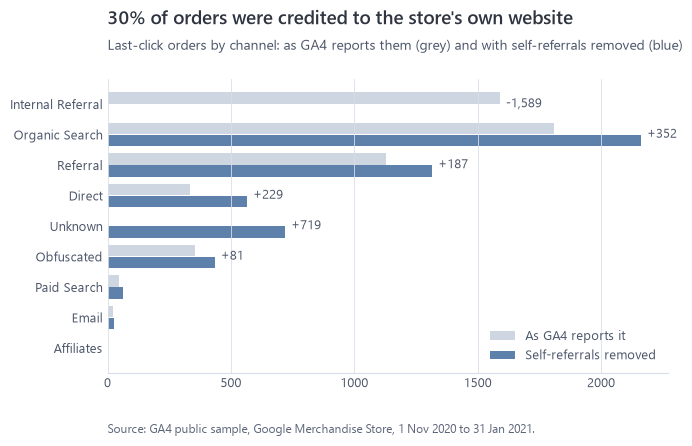

In [5]:
order = ["Internal Referral", *CHANNEL_ORDER]
d = fix.set_index("channel").reindex(order).fillna(0)
y = np.arange(len(d))[::-1]
h = 0.38

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(y + h / 2 + 0.01, d["naive_last_click"], height=h, color=GREY, label="As GA4 reports it")
ax.barh(y - h / 2 - 0.01, d["corrected_last_click"], height=h, color=BLUE, label="Self-referrals removed")
ax.set_yticks(y, d.index)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
for yi, (n, c) in zip(y, d[["naive_last_click", "corrected_last_click"]].to_numpy()):
    if max(n, c) > 150:
        ax.text(max(n, c) + 25, yi, f"{c - n:+,.0f}", va="center", color=INK_2, fontsize=9)
ax.legend(loc="lower right", labelcolor=INK_2)
finish(fig, ax, "30% of orders were credited to the store's own website",
       "Last-click orders by channel: as GA4 reports them (grey) and with self-referrals removed (blue)",
       IMG_DIR / "attribution_self_referral_fix.png", left=0.2)
plt.show()

## 3 · Seven models side by side

Share of conversions credited to each channel. Darker = more credit. Rows that stay the same colour across the row are **robust** to model choice; rows that change are where the model decision matters.

In [6]:
cmp = con.sql("SELECT model_label, channel, conversions, conversion_share FROM marts.mart_attribution_comparison").df()
model_order = ["Last click", "Last non-direct click", "First click", "Linear", "Time decay",
               "Position-based (40/20/40)", "Data-driven (Markov)"]
share = (cmp.pivot_table(index="channel", columns="model_label", values="conversion_share", aggfunc="sum")
            .reindex(index=CHANNEL_ORDER, columns=model_order).fillna(0))
(share * 100).round(1)

model_label,Last click,Last non-direct click,First click,Linear,Time decay,Position-based (40/20/40),Data-driven (Markov)
channel,,,,,,,
Organic Search,40.9,43.0,42.6,41.4,41.6,41.6,40.0
Referral,24.9,25.8,24.2,24.2,24.6,24.4,23.3
Direct,10.7,6.8,11.1,11.4,11.0,11.1,13.2
Unknown,13.6,13.6,13.6,13.6,13.6,13.6,12.2
Obfuscated,8.2,9.0,6.6,7.6,7.5,7.5,9.2
Paid Search,1.2,1.3,1.5,1.3,1.3,1.3,1.5
Email,0.5,0.5,0.4,0.5,0.5,0.5,0.5
Affiliates,0.0,0.0,0.0,0.0,0.0,0.0,0.2


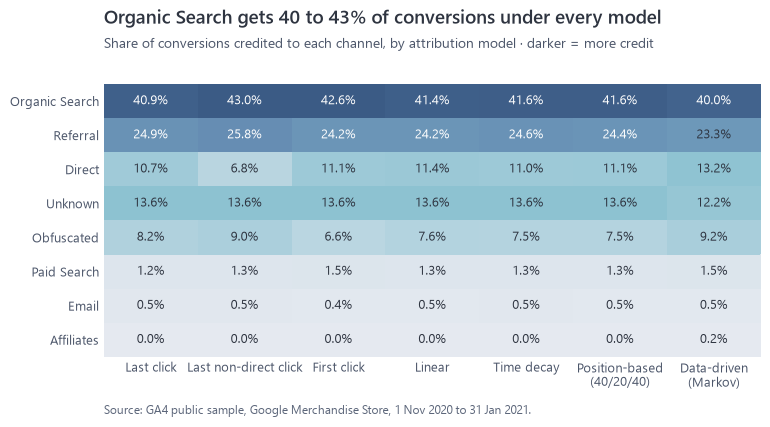

In [7]:
from matplotlib.colors import LinearSegmentedColormap

seq_blue = LinearSegmentedColormap.from_list("seq_blue", ["#E5E9F0", PAL["secondary"], PAL["primary"], PAL["primary_strong"]])
fig, ax = plt.subplots(figsize=(9, 4.4))
vals = share.to_numpy() * 100
ax.imshow(vals, cmap=seq_blue, aspect="auto", vmin=0, vmax=vals.max())
ax.set_xticks(range(len(model_order)), [m.replace(" (", "\n(") for m in model_order], fontsize=9)
ax.set_yticks(range(len(CHANNEL_ORDER)), CHANNEL_ORDER)
ax.tick_params(length=0)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f"{vals[i, j]:.1f}%", ha="center", va="center", fontsize=9,
                color="#ffffff" if vals[i, j] > vals.max() * 0.55 else INK)
finish(fig, ax, "Organic Search gets 40 to 43% of conversions under every model",
       "Share of conversions credited to each channel, by attribution model · darker = more credit",
       IMG_DIR / "attribution_model_comparison.png", top=0.78, left=0.17)
plt.show()

## 4 · Data-driven (Markov) attribution with uncertainty

Removal effect: how much would the overall conversion probability fall if a channel disappeared from every journey? Normalised removal effects become each channel's share. The 95% intervals come from 200 bootstrap resamples of journeys.

In [8]:
mk = con.sql("""
    SELECT m.channel, m.removal_effect, m.share, m.share_ci_low, m.share_ci_high,
           m.conversions AS markov_conversions, lc.conversions AS last_click_conversions, m.revenue_usd
    FROM marts.attribution_markov m
    LEFT JOIN marts.mart_attribution_comparison lc ON lc.channel = m.channel AND lc.model = 'last_click'
    WHERE m.conversions > 0.5
    ORDER BY m.share DESC
""").df()
mk["vs_last_click_pct"] = 100 * (mk["markov_conversions"] / mk["last_click_conversions"] - 1)
mk.round(3)

,channel,removal_effect,share,share_ci_low,share_ci_high,markov_conversions,last_click_conversions,revenue_usd,vs_last_click_pct
0,Organic Search,0.447,0.400,0.386,0.411,2114.456,2161.0,135291.199,-2.154
1,Referral,0.261,0.233,0.224,0.243,1234.396,1315.0,78981.526,-6.130
2,Direct,0.147,0.132,0.126,0.138,696.687,565.0,44576.760,23.307
3,Unknown,0.136,0.122,0.113,0.130,642.753,719.0,41125.887,-10.605
4,Obfuscated,0.103,0.092,0.085,0.099,487.613,434.0,31199.403,12.353
5,Paid Search,0.017,0.015,0.012,0.018,78.593,64.0,5028.667,22.801
6,Email,0.005,0.005,0.003,0.007,25.357,28.0,1622.466,-9.438
7,Affiliates,0.002,0.002,0.001,0.002,8.144,2.0,521.092,307.205


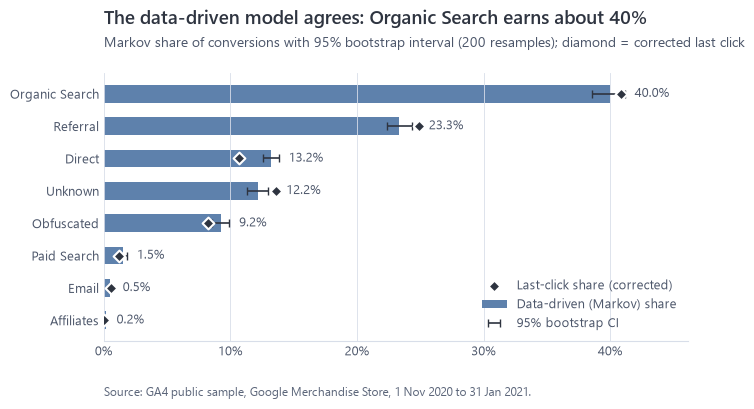

In [9]:
d = mk.set_index("channel").reindex([c for c in CHANNEL_ORDER if c in set(mk["channel"])])
y = np.arange(len(d))[::-1]
lc_share = d["last_click_conversions"] / d["last_click_conversions"].sum()

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(y, d["share"] * 100, height=0.55, color=BLUE, label="Data-driven (Markov) share")
ax.errorbar(d["share"] * 100, y,
            xerr=[(d["share"] - d["share_ci_low"]) * 100, (d["share_ci_high"] - d["share"]) * 100],
            fmt="none", ecolor=INK, elinewidth=1.2, capsize=3, label="95% bootstrap CI")
ax.scatter(lc_share * 100, y, marker="D", s=36, color=INK, edgecolor=SURFACE, linewidth=1.5, zorder=3,
           label="Last-click share (corrected)")
ax.set_yticks(y, d.index)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
# place each label just past the furthest mark on its row (bar, CI whisker or last-click marker)
label_x = np.maximum.reduce([d["share"].to_numpy(), d["share_ci_high"].to_numpy(), lc_share.to_numpy()]) * 100
for yi, s, lx in zip(y, d["share"] * 100, label_x):
    ax.text(lx + 0.8, yi, f"{s:.1f}%", va="center", color=INK_2, fontsize=9)
ax.set_xlim(0, label_x.max() + 5)
ax.legend(loc="lower right", labelcolor=INK_2)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
finish(fig, ax, "The data-driven model agrees: Organic Search earns about 40%",
       "Markov share of conversions with 95% bootstrap interval (200 resamples); diamond = corrected last click",
       IMG_DIR / "attribution_markov.png", left=0.17)
plt.show()

## 5 · Takeaways

See [`docs/attribution.md`](../docs/attribution.md) for the full write-up. In short:

1. **Fix the tracking before debating models.** Self-referrals moved more credit (about 1,600 orders) than the choice between any two attribution models did.
2. **Organic Search is the anchor channel**: ~40% of conversions, stable across all 7 models, with a tight confidence interval.
3. **Paid Search and Affiliates are undervalued by last click**: they appear earlier in journeys (introducers), so data-driven credit is higher than last-click credit.
4. **65% of orders are single-session**, so model choice only matters for ~a third of revenue, which is useful context before investing in complex attribution.
5. **Limits:** cookie-level IDs (no cross-device), 92 days of data, 9% of traffic obfuscated by Google, and **no spend data**, so this gives credit, not ROI. The MMM module adds the spend side.